In [2]:
# No Code/Low Code Visual ML Project
# Objective: Leverage no-code/low-code tools for machine learning using Tesla stock data

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, mean_squared_error

# Load the dataset
data = pd.read_csv('./TSLA.csv')

# Convert Date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Feature Engineering
# Calculate daily returns and add as a feature
data['Daily_Return'] = data['Close'].pct_change()
# Add a binary classification column: 1 if the return is positive, 0 otherwise
data['Positive_Return'] = (data['Daily_Return'] > 0).astype(int)

# Drop rows with NaN values caused by pct_change()
data = data.dropna()



In [4]:
# Select features for ML
features = ['Open', 'High', 'Low', 'Close', 'Volume']
X = data[features]
y_classification = data['Positive_Return']
y_regression = data['Close']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train_class, y_test_class = train_test_split(X_scaled, y_classification, test_size=0.2, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_scaled, y_regression, test_size=0.2, random_state=42)




In [5]:
# Classification: Random Forest
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train_class)
y_pred_class = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test_class, y_pred_class))

# Regression: Random Forest
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train_reg, y_train_reg)
y_pred_reg = reg.predict(X_test_reg)

print("Mean Squared Error for Regression:", mean_squared_error(y_test_reg, y_pred_reg))

# Clustering: Using K-Means (Optional)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
data['Cluster'] = kmeans.labels_



Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.69      0.72       303
           1       0.70      0.76      0.73       288

    accuracy                           0.73       591
   macro avg       0.73      0.73      0.73       591
weighted avg       0.73      0.73      0.73       591

Mean Squared Error for Regression: 4.05142679223406


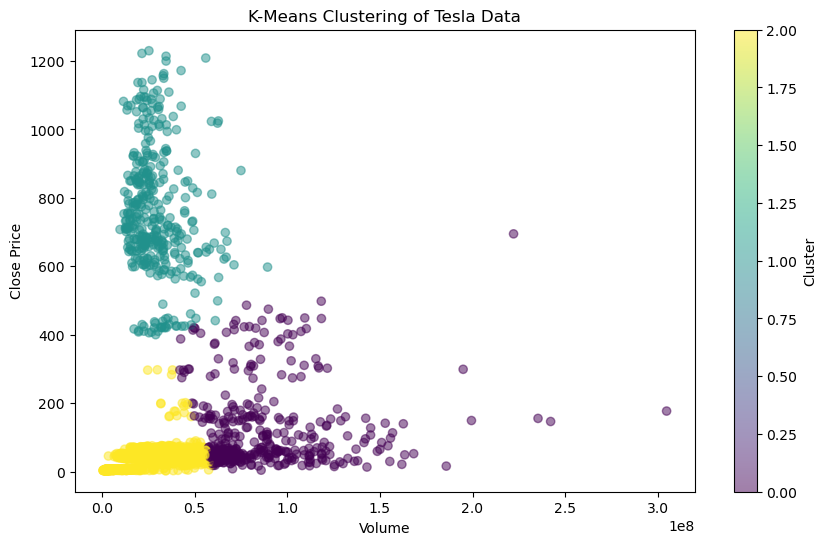

In [6]:
# Visualize clusters
plt.figure(figsize=(10, 6))
plt.scatter(data['Volume'], data['Close'], c=data['Cluster'], cmap='viridis', alpha=0.5)
plt.title('K-Means Clustering of Tesla Data')
plt.xlabel('Volume')
plt.ylabel('Close Price')
plt.colorbar(label='Cluster')
plt.show()

# Summary:
# - Classification: Predict positive/negative returns using Random Forest Classifier.
# - Regression: Predict stock closing price using Random Forest Regressor.
# - Clustering: Segment trading days into clusters based on features using K-Means.